# Nonconvex optimization with quantum Hamiltonian descent

A function of two variables has two valleys, and gradient descent from a random start often ends in the shallower one. This notebook minimizes it with NWQLib's quantum Hamiltonian descent (QHD), which moves probability across the barrier, and checks the answer against every grid point and against gradient descent.

Install with `python -m pip install "nwqlib[aer,notebook]"`. To work on NWQLib itself, run `python -m pip install -e ".[aer,notebook]"` in a clone of the repository instead. The notebook simulates at most 12 qubits and runs in about 30 s on an Apple M3 Max with 36 GiB of memory (Python 3.12.14, Qiskit 2.5.2, Aer 0.17.2).

> **How to read this notebook.** The next cells minimize the function and show the answer with its cost.
>
> - Sections 1 to 5: will it run, what it costs, how accurate, how large, what it assumes
> - Sections 6 and 7: your own objective, and constraints
> - Section 8 and Go deeper A to D: what NWQLib adds, the method in detail
> - Appendix A and B: the full resource estimate and a saved result

In [1]:
from time import perf_counter

import sympy as sp

from nwqlib import Optimization, plan, solve
from nwqlib.algorithms import QHD, QuadraticSchedule

x, y = sp.symbols("x y", real=True)
# A double well (2x² - 1)² with minima near x = ±0.71, tilted by 3x/5 so that the valley at negative x is deeper.
# The coupling 6xy/5 moves the two valleys to different y, so the function does not split into two 1D problems.
OBJECTIVE = (2 * x**2 - 1) ** 2 + sp.Rational(3, 5) * x + 2 * (y - sp.Rational(3, 10)) ** 2 + sp.Rational(6, 5) * x * y
BOUNDS = ((-1.2, 1.2), (-1.2, 1.2))  # contains both valleys, and a grid point lies 0.08 from the global minimum
GRID_POINTS = 6                       # per variable, one qubit each: 12 qubits for two variables
TOTAL_TIME = 10.0                     # long enough to concentrate the probability (Go deeper C)
SCHEDULE = QuadraticSchedule(gamma=0.3)  # weights 1/(1+γt²) and 1+γt², see Go deeper C
STEPS = 80                            # product-formula steps over the whole evolution, eight per unit time

started = perf_counter()
problem = Optimization(objective=OBJECTIVE, variables=(x, y), bounds=BOUNDS)
method = QHD(num_grid_points=GRID_POINTS, num_steps=STEPS, total_time=TOTAL_TIME, schedule=SCHEDULE)
selected = plan(problem, method=method, seed=7)  # builds the grid Hamiltonian and schedule, runs nothing
result = solve(selected, progress=False)         # simulates the circuit and returns probabilities without shots
seconds = perf_counter() - started

In [2]:
# Display helpers, the grid decoding of the result card and the classical gradient-descent baseline.
# They format values read from the records passed to them and run no plan or solve of their own.
from html import escape
import tracemalloc

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.spines.top": False, "axes.spines.right": False})


def format_value(value, digits=3):
    """Round only the display to ``digits`` significant digits. Calculations keep full precision."""
    if value is None:
        return "not available"
    if isinstance(value, (bool, np.bool_, str)):
        return str(value)
    if isinstance(value, (int, np.integer)) or isinstance(value, (float, np.floating)) and float(value).is_integer():
        return f"{int(value):,}"  # counts, including those that estimates return as floats
    if isinstance(value, (float, np.floating)):
        return f"{value:.{digits}g}"
    if isinstance(value, (tuple, list)):
        return ", ".join(format_value(item, digits) for item in value)
    return str(value)


def format_bytes(count):
    """Show a byte count in bytes and in megabytes or gigabytes."""
    if count >= 1e9:
        return f"{count:,} bytes ({count / 1e9:.3g} GB)"
    return f"{count:,} bytes" + (f" ({count / 1e6:.3g} MB)" if count >= 1e6 else "")


def show_table(rows, headers=("Quantity", "Value", "Meaning"), *, digits=3, details=None):
    """Display rows of computed quantities as a table, optionally collapsed under a summary line."""
    body = "".join("<tr>" + "".join('<td style="text-align:left">' + escape(format_value(value, digits)) + "</td>"
                                    for value in row) + "</tr>" for row in rows)
    table = ("<table><thead><tr>" + "".join("<th>" + escape(label) + "</th>" for label in headers)
             + "</tr></thead><tbody>" + body + "</tbody></table>")
    if details is not None:
        table = "<details><summary>" + escape(details) + "</summary>" + table + "</details>"
    display(HTML(table))


def traced_peak(call):
    """Run ``call()`` and return the peak bytes of Python allocations that tracemalloc saw during it."""
    tracemalloc.start()
    try:
        call()
        return tracemalloc.get_traced_memory()[1]
    finally:
        tracemalloc.stop()


def grid_probabilities(outcome, points):
    """Probability of each grid point of two variables, from the one-hot bit strings of the exact readout.

    Go deeper A explains the decoding. Outcomes without exactly one excited qubit per variable are left out.
    """
    table = np.zeros((points, points))
    histogram = outcome.data.observations.chunks[0].histogram()
    for index, value in zip(histogram.index_list(), histogram.weights.tolist()):
        bits = format(index, f"0{histogram.width}b")[::-1]  # position q is qubit q
        first, second = bits[:points], bits[points:]
        if first.count("1") == 1 and second.count("1") == 1:
            table[first.index("1"), second.index("1")] += value
    return table


def initial_marginal(points):
    """Probability of each grid value of one variable in the state that QHD starts from (Go deeper C).

    It is the ground state of the kinetic term, with amplitude proportional to sin(pi (i+1)/(K+1)) at grid point i.
    """
    amplitude = np.sin(np.pi * np.arange(1, points + 1) / (points + 1))
    return amplitude**2 / np.sum(amplitude**2)


def descent_baseline(objective, variables, bounds, points, starts=500, rate=0.01, iterations=2000):
    """Projected gradient descent: the distinct minima, the random-start success rate, the budget and the grid's valley."""
    clock = perf_counter()
    f = sp.lambdify(variables, objective)
    gradient = sp.lambdify(variables, [sp.diff(objective, v) for v in variables])
    lower, upper = np.array(bounds).T
    budget = {"runs": 0, "evaluations": 0}

    def descend(start):
        point = np.array(start, dtype=float)
        budget["runs"] += 1
        for _ in range(iterations):
            point = np.clip(point - rate * np.array(gradient(*point)), lower, upper)
            budget["evaluations"] += 1
        return point

    coarse = np.stack(np.meshgrid(*(np.linspace(lo, hi, 3) for lo, hi in bounds), indexing="ij"), axis=-1)
    minima = []  # distinct end points from a 3 x 3 set of starts, lowest objective first
    for end in sorted((descend(start) for start in coarse.reshape(-1, 2)), key=lambda p: f(*p)):
        if all(np.linalg.norm(end - point) > 0.05 for point in minima):
            minima.append(end)
    random_starts = np.random.default_rng(1).uniform(lower, upper, size=(starts, 2))
    ends = np.array([descend(start) for start in random_starts])
    grid = [np.linspace(lo, hi, points + 2)[1:-1] for lo, hi in bounds]  # the interior grid points of QHD
    grid_ends = np.array([[descend((gx, gy)) for gy in grid[1]] for gx in grid[0]])
    return dict(f=f, minima=minima, starts=random_starts, grid=grid, iterations=iterations, rate=rate,
                fraction=np.mean(np.linalg.norm(ends - minima[0], axis=1) < 0.05),
                basin=np.linalg.norm(grid_ends - minima[0], axis=-1) < 0.05,
                seconds=perf_counter() - clock, **budget)


def show_card(result, baseline, probability, values, predicted, seconds, peak_bytes):
    """Show the result card: the answer against the references, the quantum and classical cost, the maps and the steps."""
    grid = baseline["grid"]
    start = np.outer(initial_marginal(len(grid[0])), initial_marginal(len(grid[1])))
    best = np.unravel_index(values.argmin(), values.shape)
    point = ", ".join(f"{value:.3g}" for value in result.most_probable_coordinates)
    event = (f"That point is the best of all {values.size} grid points, found by evaluating each one."
             if tuple(result.most_probable_indices) == best else
             f"The best of all {values.size} grid points, found by evaluating each one, holds {probability[best]:.0%}.")
    shots = predicted.quantity("shots").fact.value.numerator
    display(HTML(
        f"<p><strong>Result.</strong> QHD puts {result.most_probable_probability:.0%} of the probability on its most "
        f"probable grid point ({point}). {event} The valley of the global minimum holds "
        f"{probability[baseline['basin']].sum():.0%} of the probability, against "
        f"{start[baseline['basin']].sum():.0%} in the state QHD starts from. Gradient descent reaches the global minimum "
        f"from {baseline['fraction']:.0%} of {len(baseline['starts'])} random starts, because each run stays in the "
        f"valley where it starts. Execution: <code>{result.data.receipts[0].target.name}</code> simulator, exact readout "
        f"of every probability. Output: probabilities of grid points, summarized by the most probable point and the "
        f"candidate, not a continuous minimizer.</p>"
        f"<p><strong>Cost.</strong> Quantum: {result.plan.reconstruction.width} qubits, "
        f"{format_value(predicted.quantity('cx').fact.value.numerator)} CX gates predicted before building (an upper bound), "
        f"{'no shots (exact readout)' if shots == 0 else f'{shots:,} shots'}. Classical: peak memory "
        f"{format_bytes(peak_bytes)} of traced Python allocations, planning work "
        f"{result.data.trace.construction_work_reserved:,} units (a planning quantity, not seconds), "
        f"{seconds:.1f} s on this computer. Gradient-descent baseline: {baseline['runs']} runs of "
        f"{baseline['iterations']:,} steps, {baseline['evaluations']:,} gradient evaluations, "
        f"{baseline['seconds']:.1f} s.</p>"))
    spacing = grid[0][1] - grid[0][0], grid[1][1] - grid[1][0]
    extent = (grid[0][0] - spacing[0] / 2, grid[0][-1] + spacing[0] / 2,
              grid[1][0] - spacing[1] / 2, grid[1][-1] + spacing[1] / 2)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), layout="constrained")
    for ax, field, title, cmap in ((axes[0], values, "Objective on the grid", "viridis"),
                                   (axes[1], probability, "QHD probability, exact readout", "magma")):
        image = ax.imshow(field.T, origin="lower", cmap=cmap, extent=extent)
        ax.set(xlabel="x", ylabel="y", title=title)
        fig.colorbar(image, ax=ax)
        for index, minimum in enumerate(baseline["minima"]):
            ax.plot(*minimum, "*" if index == 0 else "X", color="#56B4E9", markersize=14 if index == 0 else 10)
    plt.show()
    steps = (
        f"Tabulated the objective on the {len(grid[0])} interior grid points of each variable and built the grid "
        f"Hamiltonian, with a one-hot register of {len(grid[0])} qubits per variable.",
        f"Built the time-dependent schedule and the {result.plan.method.num_steps}-step product-formula circuit on "
        f"{result.plan.reconstruction.width} qubits, and simulated it on the Aer statevector simulator.",
        "Decoded the outcomes into grid points, set aside the outcomes that encode no grid point, and returned the most "
        "probable grid point and the candidate, the observed grid point with the least evaluated objective.",
    )
    display(HTML("<p><strong>What NWQLib did for you.</strong></p><ol>"
                 + "".join(f"<li>{step}</li>" for step in steps) + "</ol>"
                 + "<p>The stars mark the global minimum, the crosses the local minimum, both found by gradient "
                 "descent.</p>"))

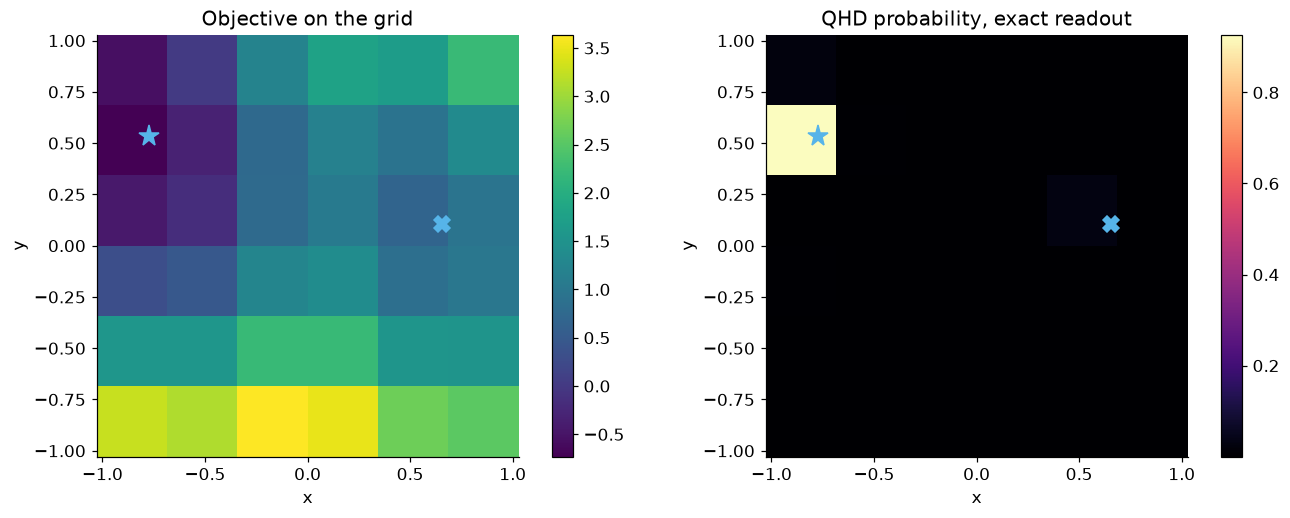

In [3]:
from nwqlib import estimate
from nwqlib.resources import ResourceContext

baseline = descent_baseline(OBJECTIVE, (x, y), BOUNDS, GRID_POINTS)    # classical comparison, about 3 s
grid = baseline["grid"]
values = baseline["f"](*np.meshgrid(*grid, indexing="ij"))            # the objective at every grid point
best = np.unravel_index(values.argmin(), values.shape)                # the best grid point, by evaluating all
probability = grid_probabilities(result, GRID_POINTS)                 # joint probability of each grid point
predicted = estimate(selected, context=ResourceContext(basis="cx"))   # counts from the resource formulas, no circuit built
peak_bytes = traced_peak(lambda: solve(plan(problem, method=method, seed=7), progress=False))
show_card(result, baseline, probability, values, predicted, seconds, peak_bytes)

**Your own objective.** Section 6 has a template cell for any SymPy objective on a box, and Section 7 adds constraints.

## 1. Will it run?

**The grid fixes the circuit's size before anything is built, and a run that does not fit is refused with the limit to change.**

- **Input.** A SymPy expression that is real everywhere in a box, the tuple of its variables, and one `(lower, upper)` interval per variable.
- **Output.** Probabilities of grid points. `result.most_probable_coordinates` is where the probability concentrates, and `result.candidate` the observed grid point with the least evaluated objective.
- **Size.** Each variable takes `num_grid_points` interior grid points. The one-hot encoding uses one qubit per grid point and variable, so $d$ variables with $K$ points each need $dK$ qubits for $K^d$ grid points.
- **Qubit limit.** The local simulator accepts 20 qubits by default, so two variables fit at most 10 grid points each on the circuit route.
- **Work and memory.** `plan` checks the objective tables and the evolution against `max_work` and `max_bytes` and refuses before forming them (Section 4).

The cell asks for 11 grid points per variable, 22 qubits. `solve` refuses before building the circuit, and the error names the limit and the amount. The remedy here is `execution="classical"`, which evolves the 121 grid amplitudes classically, one solve in under a second.

In [4]:
wide = QHD(num_grid_points=11, num_steps=STEPS, total_time=TOTAL_TIME, schedule=SCHEDULE)
wide_plan = plan(problem, method=wide, seed=7)  # tabulates the objective, builds no circuit
started = perf_counter()
try:
    solve(wide_plan, progress=False)
except ValueError as refusal:
    print(f"Refused after {perf_counter() - started:.2f} s, before any circuit existed:\n{refusal}")

host_plan = plan(problem, method=wide, seed=7, execution="classical")  # the remedy: evolve the grid classically
host_result = solve(host_plan, progress=False)
wide_grid = [np.linspace(lo, hi, 13)[1:-1] for lo, hi in BOUNDS]       # the 11 interior points per variable
wide_values = baseline["f"](*np.meshgrid(*wide_grid, indexing="ij"))
show_table([
    ("Grid points", host_plan.reconstruction.restricted_dimension, "11 per variable"),
    ("Qubits on the circuit route", wide_plan.reconstruction.width,
     f"Above max_simulation_qubits = {result.data.trace.limits.max_simulation_qubits}"),
    ("Classical workspace", format_bytes(host_plan.reconstruction.workspace_bytes), "Stated by plan before the run"),
    ("Classical work", host_plan.reconstruction.size_units, "Units, a planning quantity, not seconds"),
    ("Most probable grid point", host_result.most_probable_coordinates,
     f"Probability {format_value(host_result.most_probable_probability)}"),
    ("Its objective", host_result.most_probable_objective,
     f"Best of the {wide_values.size} grid points: {format_value(wide_values.min())}"),
], headers=('After switching to execution="classical"', "Value", "Meaning"))

Refused after 0.20 s, before any circuit existed:
selected circuit has 22 qubits, exceeding the Run's max_simulation_qubits=20 before native preparation. Raise it with limits=ExecutionLimits(max_simulation_qubits=...) in solve, prepare or Run, or with run.extend_limits(max_simulation_qubits=...) on an open Run. QHD encoding="binary" requires a periodic grid with a power-of-two num_grid_points; switching changes the grid or boundary of this computation.


"After switching to execution=""classical""",Value,Meaning
Grid points,121,11 per variable
Qubits on the circuit route,22,Above max_simulation_qubits = 20
Classical workspace,"205,904 bytes",Stated by plan before the run
Classical work,"11,174,862","Units, a planning quantity, not seconds"
Most probable grid point,"-0.8, 0.6",Probability 0.769
Its objective,-0.798,Best of the 121 grid points: -0.798


Raising `max_simulation_qubits` to 22, the error's own remedy, would simulate the 22-qubit circuit, beyond this notebook's budget.

## 2. What it costs

**`estimate` predicts the quantum cost before the circuit exists, and `plan` and the run record the classical cost.** Quantum cost means qubits, gates and shots, and classical cost means memory, work and time on this computer.

`estimate` adds up a gate-count formula for each block of the selected construction without building a circuit. `prepare` builds the circuit without running it, and `inspect_resources` compiles a copy with Qiskit. The formulas of this construction give no depth, single-qubit or T count.

In [5]:
from nwqlib import prepare

prepared = prepare(selected, progress=False)
with prepared.run:  # the prepared Run holds the circuit until the block ends
    compiled = prepared.inspect_resources(
        transpile_options={"basis_gates": ["cx", "u"], "optimization_level": 1, "seed_transpiler": 7})
predicted_cx = predicted.quantity("cx").fact.value.numerator
show_table([
    ("Qubits", predicted.quantity("logical_width", location="logical_device").fact.value.numerator,
     compiled["num_qubits"]),
    ("CX gates", f"{format_value(predicted_cx)}, an upper bound", compiled["operations"].get("cx", 0)),
    ("Shots", predicted.quantity("shots").fact.value.numerator, "None: exact readout"),
    ("Single-qubit gates", "not predicted", compiled["operations"].get("u", 0)),
    ("Depth", "not predicted", compiled["depth"]),
    ("T gates", "not predicted", "Not in the cx and u basis"),
], headers=("Quantum cost", "Predicted by estimate", "Compiled circuit"))
print(f"Compiled CX / predicted CX = {compiled['operations'].get('cx', 0) / predicted_cx:.2f} "
      f"(Qiskit optimization level 1).")

Quantum cost,Predicted by estimate,Compiled circuit
Qubits,12,12
CX gates,"13,790, an upper bound","13,790"
Shots,0,None: exact readout
Single-qubit gates,not predicted,"21,788"
Depth,not predicted,"5,786"
T gates,not predicted,Not in the cx and u basis


Compiled CX / predicted CX = 1.00 (Qiskit optimization level 1).


In [6]:
trace = result.data.trace
show_table([
    ("Peak memory", f"{format_bytes(predicted.quantity('known_memory', location='host').fact.value.numerator)} "
     "of selected arrays", format_bytes(peak_bytes)),
    ("Objective-table evaluations", selected.reconstruction.support_evaluations, "Done by plan"),
    ("Work [units, a planning quantity, not seconds]",
     f"{format_value(predicted.quantity('construction_work').fact.value.numerator)}, an upper bound",
     trace.construction_work_reserved),
    ("Stored run data", "Not predicted", format_bytes(trace.data_bytes)),
    ("Time on this computer", "Not predicted", f"{seconds:.2f} s for plan and solve, "
     f"{sum(event.timing.seconds for event in trace.events):.3f} s of it in the simulator call"),
    ("Gradient-descent baseline", f"{baseline['runs']} runs of {baseline['iterations']:,} steps",
     f"{baseline['evaluations']:,} gradient evaluations, {baseline['seconds']:.1f} s"),
], headers=("Classical cost", "Before the run", "Measured or recorded by the run"))

Classical cost,Before the run,Measured or recorded by the run
Peak memory,"1,126,400 bytes (1.13 MB) of selected arrays","35,821,466 bytes (35.8 MB)"
Objective-table evaluations,48,Done by plan
"Work [units, a planning quantity, not seconds]","53,942, an upper bound","107,884"
Stored run data,Not predicted,"1,838,364 bytes (1.84 MB)"
Time on this computer,Not predicted,"1.34 s for plan and solve, 0.221 s of it in the simulator call"
Gradient-descent baseline,"545 runs of 2,000 steps","1,090,000 gradient evaluations, 2.7 s"


- **Peak memory** is the largest total of Python allocations, traced with `tracemalloc` while the card cell repeats plan and solve. Memory that Aer allocates in C++ is not traced. `estimate` counts only the arrays of the selected construction.
- **Work.** `estimate` bounds the work of each distinct block definition once. The run records the work it counted while building the Qiskit circuit, so the two differ.
- **Baseline budget.** The baseline runs 500 descents from random starts, 9 from a 3 × 3 set of starts to locate the minima, and 36 from the grid points to mark the valley of each.
- **Not estimated:** physical qubits, error correction, run time on hardware and price.

## 3. How accurate?

**The answer is checked against a search of every grid point and against the minimum that gradient descent finds.** Each row says which kind of number it is: measured against reference, computed by the simulator, upper bound, or unavailable with its reason.

In [7]:
from nwqlib.algorithms import QHDVerification

f = baseline["f"]
check, _ = result.verify(checks=QHDVerification(comparisons=("grid_minimum",)))  # evaluates every grid point
checked = {item.frame.quantity: item.fact.value.value for application in check.applications for item in application.facts}
roundoff, roundoff_reason = result.data.receipts[0].state_error()
gap_term = selected.error_model.terms[0]
start = np.outer(initial_marginal(GRID_POINTS), initial_marginal(GRID_POINTS))  # the probabilities QHD starts from
show_table([
    ("Best grid point and its objective", ((grid[0][best[0]], grid[1][best[1]]), checked["reference_minimum"]),
     "Reference: every grid point evaluated"),
    ("Most probable point and its objective", (result.most_probable_coordinates, result.most_probable_objective),
     "From the simulated probabilities"),
    ("Most probable point's objective − grid minimum", checked["most_probable_gap"],
     "Measured against reference: every grid point evaluated"),
    ("Candidate's objective − grid minimum", checked["grid_minimum"], "Measured against reference"),
    ("Candidate's objective − continuous minimum", result.objective - f(*baseline["minima"][0]),
     f"Measured against gradient descent. Grid spacing {format_value(grid[0][1] - grid[0][0])}"),
    ("Probability at the best grid point", probability[best],
     f"Computed by the simulator, exact readout. Initial state: {format_value(start[best], 2)}"),
    ("Probability in the global minimum's valley", probability[baseline["basin"]].sum(),
     f"Computed by the simulator. Initial state: {format_value(start[baseline['basin']].sum(), 2)}"),
    ("Probability of an outcome that encodes a grid point", result.valid_probability, "Computed by the simulator"),
    ("Roundoff of the simulated state", roundoff,
     "Upper bound" if roundoff is not None else "Unavailable: " + roundoff_reason),
    ("Objective gap from all error sources", None,
     f"Unavailable: {gap_term.formula}, {gap_term.fact.fact.reason}"),
], headers=("Quantity", "Value", "Kind of number"))

Quantity,Value,Kind of number
Best grid point and its objective,"-0.857, 0.514, -0.731",Reference: every grid point evaluated
Most probable point and its objective,"-0.857, 0.514, -0.731",From the simulated probabilities
Most probable point's objective − grid minimum,0,Measured against reference: every grid point evaluated
Candidate's objective − grid minimum,0,Measured against reference
Candidate's objective − continuous minimum,0.0805,Measured against gradient descent. Grid spacing 0.343
Probability at the best grid point,0.927,"Computed by the simulator, exact readout. Initial state: 0.0094"
Probability in the global minimum's valley,0.966,Computed by the simulator. Initial state: 0.51
Probability of an outcome that encodes a grid point,1,Computed by the simulator
Roundoff of the simulated state,9.03e-09,Upper bound
Objective gap from all error sources,not available,"Unavailable: no propagated objective-gap bound, observed candidate does not establish discretization"


A grid of 36 points can be searched exhaustively on a classical computer, so the search is the reference here and not a competitor. The comparison with gradient descent concerns the mechanism. QHD moves probability across the barrier, while each descent stays in the valley where it starts.

**The total evolution time trades accuracy for circuit size.** At eight steps per unit time, a shorter evolution has fewer steps and fewer CX gates, and leaves less probability at the best grid point.

The cell solves once more at T = 2, one solve in under a second. Go deeper C sweeps the time and the schedule.

In [8]:
short = solve(plan(problem, method=QHD(num_grid_points=GRID_POINTS, num_steps=16, total_time=2.0, schedule=SCHEDULE),
                   seed=7), progress=False)
show_table([(run.plan.method.total_time, run.plan.method.num_steps,
             estimate(run.plan, context=ResourceContext(basis="cx")).quantity("cx").fact.value.numerator,
             grid_probabilities(run, GRID_POINTS)[best])
            for run in (short, result)],
           headers=("Total time T", "Steps", "Predicted CX, upper bound", "Probability at the best grid point"))

Total time T,Steps,"Predicted CX, upper bound",Probability at the best grid point
2,16,"2,782",0.172
10,80,"13,790",0.927


## 4. How large can I go?

**The local simulator sets the limit for the circuit. Beyond it, `plan` and `estimate` still give the cost.** The table lists the limits this run had and the grid's use of them.

`execution="classical"` evolves the $K^d$ grid amplitudes classically, as in Section 1, and its plan states the workspace and the work before anything runs. Its size grows as $K^d$, so it suits a few variables. [Planning at scale](resource_estimation_at_scale.ipynb) plans circuits far beyond any simulator.

In [9]:
limits = trace.limits
host_main = plan(problem, method=method, seed=7, execution="classical")  # nothing runs yet
show_table([
    ("Qubits the local simulator accepts", limits.max_simulation_qubits,
     f"Default. This grid uses {selected.reconstruction.width}"),
    ("Simulator memory cap", f"{limits.simulator_memory_mb:,} MB", "Default simulator_memory_mb"),
    ("QHD work cap", method.max_work, "Default max_work, for objective tables, products and classical evolution"),
    ("QHD memory cap", format_bytes(method.max_bytes), "Default max_bytes, for tables, state and workspace"),
    ("Classical evaluation of this grid: workspace", format_bytes(host_main.reconstruction.workspace_bytes),
     "Stated by plan before it runs"),
    ("Classical evaluation of this grid: work", host_main.reconstruction.size_units, "Units, a planning quantity, not seconds"),
], headers=("Limit or cost", "Value", "Meaning"))

Limit or cost,Value,Meaning
Qubits the local simulator accepts,20,Default. This grid uses 12
Simulator memory cap,"1,024 MB",Default simulator_memory_mb
QHD work cap,"1,000,000,000","Default max_work, for objective tables, products and classical evolution"
QHD memory cap,"10,000,000,000 bytes (10 GB)","Default max_bytes, for tables, state and workspace"
Classical evaluation of this grid: workspace,"107,304 bytes",Stated by plan before it runs
Classical evaluation of this grid: work,"2,802,127","Units, a planning quantity, not seconds"


## 5. What does it assume?

**The runs are noiseless, every count is a logical count, and the answer is a grid point.**

The circuit is read out exactly, or sampled with finite shots without noise (Go deeper B). The same finite-shot request runs with a noise model on the local simulator ([Local Aer](../docs/aer.md)), and [Choose a backend](../docs/backends.md) lists the other backends.

The library gives no bound on how far the best grid point lies from the continuous minimum (Section 3). A finer grid lowers the spacing and adds one qubit per point and variable. The grids need not be nested, so the best objective need not improve at every increase.

## 6. Your own objective

The cell below is the whole workflow without the two valleys. It minimizes a function of three variables on 4 grid points each, and compares the candidate with a search of every grid point. Replace `my_objective`, `my_variables`, `my_bounds` and `my_points` with your own.

- **Input.** A SymPy expression, the tuple of its variables in the order you want them reported, and one `(lower, upper)` interval per variable. The expression must be real everywhere in the box.
- **Grid.** Each variable takes `num_grid_points` interior points of its interval, spaced `(upper - lower) / (num_grid_points + 1)` apart, so the grid never touches the bounds.
- **Size limits.** The cell uses $d=3$ variables and $K=4$ points: 12 qubits and 64 grid points. Keep $dK$ within 20 qubits for the local simulator, or use `execution="classical"` (Section 1).
- **Output.** `my_result.most_probable_coordinates` is the most probable grid point, in the order of `my_variables`, with `my_result.most_probable_probability`. `my_result.candidate` is the observed grid point with the least evaluated objective, and `my_result.objective` its value. `my_result.marginals.array` holds one row of grid-value probabilities per variable.

In [10]:
import numpy as np
import sympy as sp

from nwqlib import Optimization, plan, solve
from nwqlib.algorithms import QHD, QuadraticSchedule

a, b, c = sp.symbols("a b c", real=True)
my_objective = ((a**2 - 1) ** 2 + sp.Rational(3, 10) * a + (b - sp.Rational(1, 2)) ** 2
                + (c + sp.Rational(3, 10)) ** 2 + sp.Rational(1, 2) * a * c)  # your objective
my_variables = (a, b, c)                                                     # its variables, in order
my_bounds = ((-1.5, 1.5), (-1.5, 1.5), (-1.5, 1.5))                          # one interval per variable

my_points = 4                                                                # grid points per variable

my_plan = plan(Optimization(objective=my_objective, variables=my_variables, bounds=my_bounds),
               method=QHD(num_grid_points=my_points, num_steps=80, total_time=10.0,
                          schedule=QuadraticSchedule(gamma=0.3)), seed=7)  # runs nothing
my_result = solve(my_plan, progress=False)
print(f"most probable point {np.round(my_result.most_probable_coordinates, 3)}, "
      f"objective {my_result.most_probable_objective:.3g}, probability {my_result.most_probable_probability:.2f} "
      f"(uniform {1 / my_points ** len(my_variables):.3f})")
print(f"candidate {np.round(my_result.candidate, 3)}, objective {my_result.objective:.3g}")

my_grid = [np.linspace(lo, hi, my_points + 2)[1:-1] for lo, hi in my_bounds]  # the interior grid points
my_values = sp.lambdify(my_variables, my_objective)(*np.meshgrid(*my_grid, indexing="ij"))
print(f"search of all {my_values.size} grid points: smallest objective {my_values.min():.3g}")

most probable point [-0.9  0.3 -0.3], objective -0.0589, probability 0.43 (uniform 0.016)
candidate [-0.9  0.3 -0.3], objective -0.0589
search of all 64 grid points: smallest objective -0.0589


## 7. Adding constraints

**A `ConstrainedOptimization` adds equalities $h_i(x)=0$ and inequalities $g_j(x)\le 0$, and `solve_augmented_lagrangian` solves it by a sequence of ordinary QHD solves, called rounds.**

Each round adds multiplier and penalty terms to the objective, runs QHD on that effective objective, reads one point and updates the multipliers and the penalty there. The [QHD guide](../docs/algorithms/qhd.md#constrained-problems) gives the formulas and their sources.

The cell minimizes $(x-1)^2+(y-1)^2$ on the unit disk $x^2+y^2\le 1$. The continuous solution is $x^\star=(1/\sqrt2,1/\sqrt2)$ with $f^\star=3-2\sqrt2$, where the constraint is active with multiplier $\sqrt2-1$.

On the box $[0,1]^2$ with 4 grid points per variable, the grid has 16 points on 8 qubits. Two of them, $(0.6,0.8)$ and $(0.8,0.6)$, lie on the circle. Every round uses the schedule, steps and total time of the two-valley example.

In [11]:
import sympy as sp

from nwqlib import ConstrainedOptimization
from nwqlib.algorithms import QHD, QuadraticSchedule, constrained_grid_minimum, solve_augmented_lagrangian

x, y = sp.symbols("x y", real=True)
DISK_BOUNDS = ((0.0, 1.0), (0.0, 1.0))  # contains x*, and the grid points (0.6, 0.8) and (0.8, 0.6) lie on the circle
DISK_POINTS = 4                         # per variable: 16 grid points on 8 qubits

disk_problem = ConstrainedOptimization(objective=(x - 1) ** 2 + (y - 1) ** 2, variables=(x, y), bounds=DISK_BOUNDS,
                                       inequalities=(x**2 + y**2 - 1,))  # each entry g means g(x, y) <= 0
disk_method = QHD(num_grid_points=DISK_POINTS, num_steps=80, total_time=10.0, schedule=QuadraticSchedule(gamma=0.3))
disk = solve_augmented_lagrangian(disk_problem, qhd=disk_method, execution="classical", seed=7, progress=False)
disk_reference = constrained_grid_minimum(disk)  # evaluates f and g at all 16 grid points

With `execution="classical"` the rounds evolve the finite-difference grid model classically and simulate no circuit. A circuit for a round's effective objective also splits the potential, the kinetic operator and the one-hot links, so its distribution can differ at the same step count.

The next cell therefore prices that circuit for each round and runs it at the same 80 steps. Its table sets the classical work beside the circuit cost and each round's point beside the circuit's probability there.

Compare the two distributions before reading the circuit cost as the cost of reproducing the classical rounds.

In [12]:
from nwqlib import estimate, plan, solve
from nwqlib.resources import ResourceContext

corner = np.full(2, 1 / np.sqrt(2))  # the continuous solution x*
optimum = 3 - 2 * np.sqrt(2)         # f(x*)
disk_g = disk.best.evaluation.inequality_residuals[0]
disk_distance = np.linalg.norm(np.array(disk.candidate) - corner)
# Classical rounds build no circuit. Each round's effective objective is planned again for quantum execution,
# estimate adds up the CX formulas of that Plan, and solve runs its 8-qubit circuit with exact readout.
round_plans = [plan(inner.plan.problem, method=disk_method, seed=7) for inner in disk.results]
round_cx = [estimate(p, context=ResourceContext(basis="cx")).quantity("cx").fact.value.numerator for p in round_plans]
round_circuits = [solve(p, progress=False) for p in round_plans]
# The circuit's probability at the grid point that each round read, and whether its most probable point is that point.
round_circuit_p = [grid_probabilities(circuit, DISK_POINTS)[tuple(inner.most_probable_indices)]
                   for circuit, inner in zip(round_circuits, disk.results)]
round_same_point = sum(tuple(circuit.most_probable_indices) == tuple(inner.most_probable_indices)
                       for circuit, inner in zip(round_circuits, disk.results))
if disk_reference.gap is None:
    found = "No feasible grid point or no best point is available for this comparison."
elif disk_reference.gap == 0:
    found = (f"The objective at its best point ({format_value(disk.candidate)}) equals the least evaluated objective "
             "among the feasible grid points.")
else:
    found = (f"The objective at its best point ({format_value(disk.candidate)}) has a signed difference of "
             f"{format_value(disk_reference.gap)} from the least evaluated objective among the feasible grid points, "
             f"found at ({format_value(disk_reference.point)}).")
display(HTML(
    f"<p><strong>Result.</strong> The run stopped after {len(disk.iterations)} rounds with status "
    f"<code>{disk.termination}</code>. {found} <code>constrained_grid_minimum</code> evaluates f and g at every grid "
    f"point for this comparison. The best point lies {format_value(disk_distance)} from the continuous solution, with "
    f"an objective {format_value(disk.objective - optimum)} above f*.</p>"))
show_table([
    ("Best point", disk.candidate, f"Round {disk.best.iteration + 1}. x* = {format_value(tuple(corner))}"),
    ("Objective f", disk.objective, f"f* = {format_value(optimum)}"),
    ("Constraint value g", disk_g,
     f"Feasible when g ≤ {format_value(disk.record.feasibility_tolerance)}, on the circle g = 0"),
    ("Least evaluated feasible objective", disk_reference.objective,
     f"{disk_reference.feasible_points} of {disk_reference.grid_points} grid points pass the computed feasibility test"),
    ("Distance to x*", disk_distance,
     f"Grid spacing {format_value((DISK_BOUNDS[0][1] - DISK_BOUNDS[0][0]) / (DISK_POINTS + 1))}"),
    ("f − f*", disk.objective - optimum, f"(1 − √2) g + √2 |p − x*|² = "
     f"{format_value((1 - np.sqrt(2)) * disk_g + np.sqrt(2) * disk_distance**2)}"),
    ("Multiplier iterate", disk.multipliers()[1][0],
     f"The method's multiplier after its last round on the {disk_reference.grid_points}-point grid"),
    ("Final penalty", disk.penalty, "Of the last round"),
    ("Point rule, stopping rule", f"{disk.record.options.inner_point}, {disk.record.options.termination}",
     "Defaults of AugmentedLagrangian"),
    ("Classical work", f"{disk.resources.table_evaluations} objective-table evaluations, "
     f"{disk.resources.evolution_work:,} units of classical-evolution work (a planning quantity, not seconds)",
     f"QHD planning checks each counted part of a round's work against max_work = {disk_method.max_work:,} "
     "before running it"),
    ("Circuit cost of a quantum run", f"{len(round_cx)} circuits of {disk.resources.width} qubits, at most "
     f"{sum(round_cx):,} CX gates", f"Per round {' / '.join(format_value(cx) for cx in round_cx)}, upper bounds from a "
     f"Plan built for quantum execution of each round's effective objective with {disk_method.num_steps} steps"),
    ("Probability of each round's point, classical round",
     " / ".join(format_value(inner.most_probable_probability) for inner in disk.results),
     f"Circuit of that round at {disk_method.num_steps} steps: "
     + " / ".join(format_value(p) for p in round_circuit_p)
     + f". The circuit's most probable point is the round's point in {round_same_point} of {len(round_circuits)} rounds"),
])
display(HTML("<p><strong>What the status means.</strong> " + escape(disk.report()["statements"][0]) + "</p>"))
show_table([(item.iteration + 1, item.penalty, item.inequality_multipliers[0], item.evaluation.point,
             item.evaluation.probability, item.evaluation.inequality_residuals[0], p, circuit.most_probable_coordinates)
            for item, p, circuit in zip(disk.iterations, round_circuit_p, round_circuits)],
           headers=("Round", "Penalty", "Multiplier used", "Point read", "Its probability", "g at the point",
                    "Circuit's probability there", "Circuit's most probable point"),
           details="Every round")

Quantity,Value,Meaning
Best point,"0.6, 0.8","Round 3. x* = 0.707, 0.707"
Objective f,0.2,f* = 0.172
Constraint value g,2.22e-16,"Feasible when g ≤ 1e-09, on the circle g = 0"
Least evaluated feasible objective,0.2,15 of 16 grid points pass the computed feasibility test
Distance to x*,0.142,Grid spacing 0.2
f − f*,0.0284,(1 − √2) g + √2 |p − x*|² = 0.0284
Multiplier iterate,0.56,The method's multiplier after its last round on the 16-point grid
Final penalty,2,Of the last round
"Point rule, stopping rule","most_probable, feasibility_and_complementarity",Defaults of AugmentedLagrangian
Classical work,"72 objective-table evaluations, 2,725,845 units of classical-evolution work (a planning quantity, not seconds)","QHD planning checks each counted part of a round's work against max_work = 1,000,000,000 before running it"


Round,Penalty,Multiplier used,Point read,Its probability,g at the point,Circuit's probability there,Circuit's most probable point
1,1,0,"0.8, 0.8",0.954,0.28,0.872,"0.8, 0.8"
2,1,0.28,"0.8, 0.8",0.453,0.28,0.365,"0.8, 0.8"
3,2,0.56,"0.6, 0.8",0.432,2.22e-16,0.438,"0.6, 0.8"


**The stopping status says why the run ended, and it is not an optimality certificate, even on the grid.** `constrained_grid_minimum` evaluates $f$, $h$ and $g$ on all $K^d$ grid points and finds the least evaluated objective among those that pass the computed feasibility test. It suits small grids.

<details><summary>The returned point against the continuous solution, and what the grid check establishes</summary>

For every point $p$,

$$f(p)-f^\star=(1-\sqrt2)\,g(p)+\sqrt2\,\lVert p-x^\star\rVert^2.$$

This holds because the Lagrangian $f+(\sqrt2-1)\,g$ is a quadratic that equals $f^\star$ at $x^\star$, where $g=0$, whose gradient vanishes there and whose Hessian is $2\sqrt2$ times the identity.

A point on the circle, where $g=0$, lies above $f^\star$ by $\sqrt2$ times its squared distance from $x^\star$. A point inside the disk, where $g<0$, adds $(\sqrt2-1)\lvert g\rvert$.

The grid points $(0.6,0.8)$ and $(0.8,0.6)$ have $g=0$ in exact arithmetic, so a computed $g$ of order $10^{-16}$ at either one is rounding.

The multiplier that the run reports is the method's iterate after its last round on the 16-point grid. Nothing requires it to equal the continuous multiplier $\sqrt2-1$.

`constrained_grid_minimum(result)` checks its work against its limit before evaluating. Its signed difference subtracts the freshly evaluated minimum from the result's stored best objective.

That difference can be negative, including when the stored point belongs to the evaluated feasible grid, because the two values can have different rounding errors. An off-grid or infeasible stored point gives no grid-optimality conclusion.

If no grid point passes computed feasibility, its point, objective and gap are `None`. The gap is also `None` when the result has no best point.

The signed difference is an evaluated-value diagnostic. A bound for the mathematical objective requires bounds for objective-evaluation error and an appropriate feasible comparison set, and no conclusion about the continuous problem follows.

</details>

**Your own constraints.**

- **Constraints.** Each entry of `equalities` is a SymPy expression $h$ with $h=0$, and each entry of `inequalities` an expression $g$ with $g\le 0$. A problem with an equality must set `feasibility_tolerance`, because a grid seldom contains a point where $h=0$ exactly.
- **Options.** `options=AugmentedLagrangian(...)`, imported from `nwqlib.algorithms`, sets the penalty, the tolerances, scales for constraints in different units, the point rule and the stopping rule. Go deeper D covers slack variables for inequalities.
- **Cost.** Each round is one QHD solve on the same grid, and a run makes at most `max_iterations` of them. A larger penalty can increase the effective objective's range and the counted work of classical evolution. The range need not increase monotonically, because the objective, multiplier term and penalty can cancel.
- **Refusal.** A later round whose planning exceeds `max_work` ends the run with status `inner_failed`.

## 8. What NWQLib adds

- **Planning beyond simulation.** `plan` and `estimate` work at sizes no simulator holds ([Planning at scale](resource_estimation_at_scale.ipynb)).
- **The formula behind every number.** Each predicted count comes from a gate-count formula per block ([Mathematics](../docs/mathematics.md)). Section 2 sets the CX upper bound beside the compiled circuit, and the resource notebook compares the formulas with compiled circuits at small sizes.
- **One argument switches the route.** `execution="classical"` evolves the grid classically instead of simulating the circuit (Sections 1 and 7). `QHD(encoding="binary")` uses $\log_2 K$ qubits per variable on a periodic grid (Go deeper D).
- **Saved and reloaded.** A saved result reloads with its plan, and its numbers can be recomputed from it (Appendix B).

[Why NWQLib](../docs/why_nwqlib.md) compares this workflow with other packages.

## Go deeper

### A. The probability of every grid point

**How do the measured bit strings become grid points, and how much probability lies in each valley?** This section decodes the exact readout of the main solve and runs no new solve.

Each outcome of the 12-qubit register is a bit string. Qubits 0 to 5, the six rightmost characters, encode $x$, and qubits 6 to 11 encode $y$. A valid outcome has exactly one excited qubit in each group, whose position in the group is the grid index.

`result.marginals` sums the probabilities over one variable. The joint probability of each grid point, which the map in the result card shows, needs the bit strings of `result.data.observations`, which `grid_probabilities` in the collapsed helper cell decodes. The table lists the five most probable outcomes.

"Bit string, qubit 0 rightmost","Grid index (x, y)",Probability
010000000001,"0, 4",0.927
001000010000,"4, 3",0.0324
100000000001,"0, 5",0.0246
010000000010,"1, 4",0.00562
000100000001,"0, 2",0.00386


Quantity,Value,Meaning
Probability in the valley of the global minimum,0.966,19 grid points from which gradient descent reaches it
Probability in the other valley,0.034,The remaining grid points
Largest difference from result.marginals,2.71e-20,Row sums of the joint probability against the marginal of x


Quantity,Value,Meaning
Computed probability maximizer,"-0.857, 0.514","Largest computed probability, lexicographically first on exact ties"
Tie representative,"-0.857, 0.514",The most probable point that the result reports
Tie window and deficit,"1.81e-08, 0","Numerical window of the selection, and how far the point lies below the computed maximum"
Mode status,resolved,Unresolved when another positive observed valid point passes the tie test
Expected objective,-0.668,Initial state: 1.14


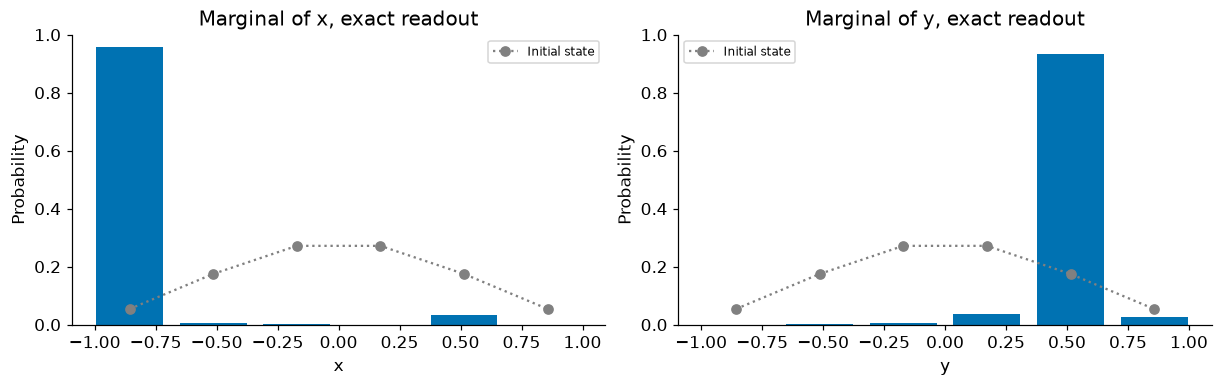

In [13]:
histogram = result.data.observations.chunks[0].histogram()
outcomes = sorted(zip((format(index, f"0{histogram.width}b") for index in histogram.index_list()),
                      histogram.weights.tolist()), key=lambda item: -item[1])[:5]
show_table([(bits, tuple(bits[::-1][j * GRID_POINTS:(j + 1) * GRID_POINTS].index("1") for j in range(2)),
             value) for bits, value in outcomes],
           headers=("Bit string, qubit 0 rightmost", "Grid index (x, y)", "Probability"))
show_table([
    ("Probability in the valley of the global minimum", probability[baseline["basin"]].sum(),
     f"{baseline['basin'].sum()} grid points from which gradient descent reaches it"),
    ("Probability in the other valley", probability[~baseline["basin"]].sum(), "The remaining grid points"),
    ("Largest difference from result.marginals", np.abs(probability.sum(axis=1) - result.marginals.array[0]).max(),
     "Row sums of the joint probability against the marginal of x"),
])
show_table([
    ("Computed probability maximizer", result.probability_maximizer_coordinates,
     "Largest computed probability, lexicographically first on exact ties"),
    ("Tie representative", result.most_probable_coordinates, "The most probable point that the result reports"),
    ("Tie window and deficit", (result.most_probable_tie_window, result.most_probable_deficit),
     "Numerical window of the selection, and how far the point lies below the computed maximum"),
    ("Mode status", result.mode_status, "Unresolved when another positive observed valid point passes the tie test"),
    ("Expected objective", result.expected_objective, f"Initial state: {format_value((start * values).sum())}"),
], details="How the most probable point is selected")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), layout="constrained")
for ax, name, points, marginal in zip(axes, ("x", "y"), grid, result.marginals.array, strict=True):
    ax.bar(points, marginal, width=0.8 * (points[1] - points[0]), color="#0072B2")
    ax.plot(points, initial_marginal(len(points)), "o:", color="0.5", label="Initial state")
    ax.set(xlabel=name, ylabel="Probability", ylim=(0, 1), title=f"Marginal of {name}, exact readout")
    ax.legend(fontsize=8)
plt.show()

### B. A finite number of measurements

**What does a run on hardware return, and how often does it miss the best grid point?** One solve with 20 shots on the noiseless Aer simulator, under 2 s.

Each shot measures the encoded register. A one-hot outcome can be invalid, and the analysis reports that mass separately. The sampled candidate has the least evaluated objective among positive-count valid outcomes and is unavailable if none was observed.

For a fixed circuit and a success event with unconditional probability $p$, $S$ independent repetitions all miss it with probability $(1-p)^S$. The table takes as the event a shot at the best grid point, with $p$ its exact probability from Go deeper A, and $S=20$.

In [14]:
sampled = solve(plan(problem, method=method, shots=20, seed=7), progress=False)
show_table([
    ("Candidate", sampled.candidate, "Least evaluated objective among the sampled valid outcomes"),
    ("Objective at the candidate", sampled.objective, f"Best grid value {format_value(values[best])}"),
    ("Fraction of samples at the candidate", sampled.candidate_probability, "Empirical"),
    ("Valid one-hot fraction", sampled.valid_probability, "Fraction of samples that encode a grid point"),
    ("Chance that 20 shots all miss the best grid point", (1 - probability[best]) ** 20,
     f"(1 − p)^20 with p = {format_value(probability[best])}, its exact probability"),
])

Quantity,Value,Meaning
Candidate,"-0.857, 0.514",Least evaluated objective among the sampled valid outcomes
Objective at the candidate,-0.731,Best grid value -0.731
Fraction of samples at the candidate,0.9,Empirical
Valid one-hot fraction,1,Fraction of samples that encode a grid point
Chance that 20 shots all miss the best grid point,1.9e-23,"(1 − p)^20 with p = 0.927, its exact probability"


### C. The Hamiltonian and how the schedule decides success

**How do the total time and the schedule strength $\gamma$ change the probability at the best grid point?** The cell repeats the solve for five total times and three schedule strengths, keeping eight product-formula steps per unit time, 15 solves in about 12 s.

QHD evolves a wavefunction $\psi(x,y,t)$ under the time-dependent Hamiltonian

$$H(t)=\frac{1}{1+\gamma t^2}\left(-\frac{\nabla^2}{2}\right)+\left(1+\gamma t^2\right)f(x,y).$$

At early times the kinetic term dominates, so the wavefunction spreads and can cross the barrier between the valleys. As $t$ grows, the potential term takes over and the wavefunction concentrates where $f$ is small. With $\gamma=0$ both weights stay constant and nothing forces the concentration.

On the grid, the kinetic term becomes hopping between neighboring grid points. The evolution uses `STEPS` steps of a second-order product formula, with each step's schedule weights taken at its midpoint time.

The evolution starts from the ground state of the kinetic term on the grid, because that term dominates at early times. Its amplitude at grid point $i$ of each variable is proportional to $\sin\bigl(\pi(i+1)/(K+1)\bigr)$ for $K$ grid points. `QHD(initial_state=UniformState())` starts from the uniform superposition of Leng et al. instead.

<details><summary>Sources of the Hamiltonian, the schedule and the encoding</summary>

QHD is due to Leng, Hickman, Li and Wu, [arXiv:2303.01471v1](https://arxiv.org/abs/2303.01471v1). The Hamiltonian is their Eq. (1), with the weights $e^{\varphi_t}=1/(1+\gamma t^2)$ and $e^{\chi_t}=1+\gamma t^2$. Their ratio $(1+\gamma t^2)^{-2}$ tends to zero for $\gamma>0$, as the paper requires after Eq. (1).

This quadratic schedule, NWQLib's default `QuadraticSchedule`, is the one that QHDOPT ([arXiv:2409.03121v1](https://arxiv.org/abs/2409.03121v1), Sec. 2.1) recommends for general nonconvex problems. Leng et al.'s numerical experiments (App. C.2.1) use the cubic schedule of their Eq. (C.4), which `CubicSchedule` provides.

The hopping term uses the central-difference stencil of Leng et al. Eq. (F.7). The potential follows the occupation-operator encoding of Wu et al., [arXiv:2605.12066v1](https://arxiv.org/abs/2605.12066v1), Sec. IV.A, Eqs. (9)–(10). The source map of the [QHD guide](../docs/algorithms/qhd.md) gives the source of each step, with the paper location and page where one exists.

</details>

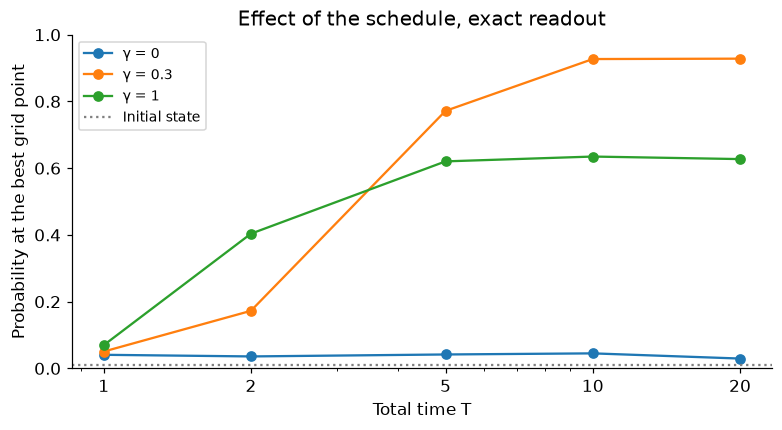

In [15]:
times, gammas = (1.0, 2.0, 5.0, 10.0, 20.0), (0.0, 0.3, 1.0)
sweep = [[solve(problem, method=QHD(num_grid_points=GRID_POINTS, num_steps=int(8 * time), total_time=time,
                                    schedule=QuadraticSchedule(gamma=gamma)), seed=7, progress=False)
          for gamma in gammas] for time in times]
success = np.array([[grid_probabilities(item, GRID_POINTS)[best] for item in row] for row in sweep])
fig, ax = plt.subplots(figsize=(7, 3.8), layout="constrained")
for column, gamma in enumerate(gammas):
    ax.plot(times, success[:, column], "o-", label=f"γ = {gamma:g}")
ax.axhline(start[best], color="0.5", linestyle=":", label="Initial state")
ax.set(xscale="log", xticks=times, xticklabels=[format_value(t) for t in times], xlabel="Total time T",
       ylabel="Probability at the best grid point", ylim=(0, 1), title="Effect of the schedule, exact readout")
ax.legend(fontsize=9)
plt.show()

Without a schedule ($\gamma=0$) the kinetic term never gives way, and the probability at the best grid point stays low. In this example $\gamma=1$ concentrates the probability sooner but levels off lower than $\gamma=0.3$, so the schedule strength is a parameter to tune for each problem rather than to maximize.

### D. Slack variables for inequality constraints

**When does an inequality become an extra grid variable, and what does it cost?** The first cell plans round 0 of three options and runs nothing. The second solves the disk problem of Section 7 with a slack variable, classically.

`AugmentedLagrangian(inequality_form="phr")` is the default. It keeps the Powell–Hestenes–Rockafellar (PHR) term for every kept inequality. `inequality_form="slack"` requests explicit slack coordinates after the eligible quadratic and constant branch tests.

`inequality_form="auto"` selects a representation by the execution rule below. Each converted inequality appends one normalized slack coordinate to the inner problem, after the original variables and in constraint order.

An unsimplified PHR term involving $r$ variables needs a support table with `K**r` entries. If the normalized inequality is additively separable after grouping by variable, expanding its slack term produces supports of at most two variables.

The cell plans the three options for the affine family of the [QHD guide](../docs/algorithms/qhd.md#slack-variables-for-inequality-constraints), $f=\sum_i(x_i-1/2)^2$ and $g=\sum_i x_i-3\le 0$ on $[0,1]^8$. It uses the binary periodic grid with $K=4$ points per variable, one step and total time 0.001.

`plan_augmented_lagrangian(problem, *, qhd, options, execution, shots, seed)` returns `(preprocessing, representation, plan)` for an unrefined round 0. It performs preprocessing, representation selection and QHD planning, with no Run, circuit preparation, evolution or grid-reference solve. Its counts are planning and resource-formula results, not runtime measurements.

In [16]:
from nwqlib.algorithms import AugmentedLagrangian, plan_augmented_lagrangian

xs = sp.symbols("x0:8", real=True)
affine = ConstrainedOptimization(objective=sum((v - sp.Rational(1, 2)) ** 2 for v in xs), variables=xs,
                                 bounds=((0.0, 1.0),) * 8, inequalities=(sum(xs) - 3,))  # g <= 0
binary_qhd = QHD(num_grid_points=4, encoding="binary", boundary="periodic", num_steps=1, total_time=0.001)
round0 = {form: plan_augmented_lagrangian(affine, qhd=binary_qhd, options=AugmentedLagrangian(inequality_form=form),
                                          execution="quantum", seed=7)  # plans round 0 only and runs nothing
          for form in ("phr", "slack", "auto")}
rows = []
for form, (_, representation, round_plan) in round0.items():
    tables = round_plan.reconstruction.support_values  # one table of objective values per support
    rows.append((form, "no representation" if representation is None else ", ".join(representation.forms),
                 len(round_plan.problem.variables), round_plan.reconstruction.width,
                 max(len(table.support) for table in tables), sum(len(table.values) for table in tables),
                 estimate(round_plan, context=ResourceContext(basis="cx")).quantity("cx").fact.value.numerator))
show_table(rows, headers=("inequality_form", "Form of g", "Inner variables", "Qubits", "Largest support",
                          "Table entries", "CX per circuit, planned"))
trial, = round0["auto"][1].trials  # the one trial conversion of automatic selection
show_table([("Planned classical work", trial.current_work, trial.trial_work),
            ("CX per circuit", trial.current_cx, trial.trial_cx)],
           headers=("Automatic selection, planning only", "Current form: PHR", "Trial: one slack variable"))
display(HTML(f"<p>Trial accepted: {trial.accepted}, {escape(trial.reason)}.</p>"))

inequality_form,Form of g,Inner variables,Qubits,Largest support,Table entries,"CX per circuit, planned"
phr,no representation,8,16,8,"65,568","131,148"
slack,slack,9,18,2,612,666
auto,slack,9,18,2,612,666


"Automatic selection, planning only",Current form: PHR,Trial: one slack variable
Planned classical work,"12,326,697","39,673"
CX per circuit,"131,148",666


Automatic conversion is enabled only for `execution="quantum"`, including Plans that will run on Aer and quantum planning without execution. It makes one deterministic pass through kept inequalities in original order.

Each trial adds one slack to the representation accepted so far. When planning accepts both Plans, the rule accepts the trial only if planned classical work and CX per circuit are both no larger and at least one is strictly smaller.

The classical-work comparison is the work counted by QHD's symbolic and table checks plus the circuit construction work. It is a planning metric, not a runtime measurement or a sum of the work of all trials.

Quantum Plans use this circuit-cost rule even when their eventual backend is a statevector simulator, so a lower CX count alone does not promise a faster Aer run.

For fourteen original variables of the same family, the guide reports that PHR was refused before its table was formed, while forced slack required 1,830 CX per circuit. These are planning numbers from the guide, not runs of this notebook.

Under `execution="classical"`, automatic selection keeps every inequality in PHR form for both `theory_flavor="schrodinger"` and `theory_flavor="split_step"`. Their restricted state has `K**d` amplitudes and becomes `K**(d+m_s)` with $m_s$ added slack axes.

Forced slack remains available on either route. The next cell therefore solves the disk problem of Section 7 again with `inequality_form="slack"` and `execution="classical"`, and compares its result with `constrained_grid_minimum`.

In [17]:
slack_disk = solve_augmented_lagrangian(disk_problem, qhd=disk_method, execution="classical", seed=7, progress=False,
                                        options=AugmentedLagrangian(inequality_form="slack"))
slack_check = constrained_grid_minimum(slack_disk)  # the same 16-point comparison as for the PHR run
slack_forms = slack_disk.report()["inequality_forms"]  # per round, the form of each inequality by problem position
display(HTML(
    f"<p><strong>Result with a slack variable.</strong> The run stopped after {len(slack_disk.iterations)} rounds "
    f"with status <code>{slack_disk.termination}</code> at the point ({format_value(slack_disk.candidate)}) with "
    f"objective {format_value(slack_disk.objective)}. Its signed difference from the least evaluated feasible "
    f"objective of <code>constrained_grid_minimum</code> is {format_value(slack_check.gap)}. The PHR run of Section 7 "
    f"stopped after {len(disk.iterations)} rounds at ({format_value(disk.candidate)}).</p>"))
show_table([(item.iteration + 1, ", ".join(slack_forms[item.iteration]["forms"].values()),
             [(axis.upper, axis.spacing) for axis in item.representation.slacks],
             slack_forms[item.iteration]["slack_error_bound"], item.evaluation.point, item.evaluation.slack_point,
             item.evaluation.probability, item.evaluation.inequality_residuals[0],
             (item.evaluation.effective_value, item.evaluation.effective_value_source),
             (item.evaluation.inner_value, item.evaluation.inner_value_source))
            for item in slack_disk.iterations],
           headers=("Round", "Form of g", "Slack box end U and spacing h", "Slack-grid bound", "Projected point x",
                    "Slack coordinate s", "Probability of the joint point", "g at x", "effective_value, source",
                    "inner_value, source"))

Round,Form of g,Slack box end U and spacing h,Slack-grid bound,Projected point x,Slack coordinate s,Probability of the joint point,g at x,"effective_value, source","inner_value, source"
1,slack,"0.92, 0.184",0.0684,"0.8, 0.8",0.184,0.767,0.28,"0.119, evaluated","0.188, table"
2,slack,"0.92, 0.184",0.12,"0.6, 0.8",0.184,0.369,2.22e-16,"0.2, evaluated","0.268, table"


The slack changes the inner problem, and the outer state remains that of the PHR algorithm. The round selects a joint inner point, projects it to x, and evaluates the original f, h and kept g there.

Its tentative multipliers are `lambda+ = lambda_bar + rho H(x)` and `mu+ = max(0, mu_bar + rho G(x))`. The safeguard, penalty rule, stopping tests and stationarity diagnostic use those projected original residuals. The sampled slack and `G_j(x) + s_j` do not replace them.

The slack coordinate has the units of normalized G_j, so the corresponding original-unit expression is `g_j(x) + s_{g,j} s_j`.

<details><summary>The slack minimizer and the PHR term</summary>

For $G_j=g_j/s_{g,j}$, entering multiplier $\bar\mu_j\ge 0$ and penalty $\rho>0$, define the PHR term $P_j$. The continuous slack minimizer and its value satisfy

$$P_j(t)=\frac{[\bar\mu_j+\rho t]_+^2-\bar\mu_j^2}{2\rho},\qquad s_j^*(x)=[-G_j(x)-\bar\mu_j/\rho]_+,\qquad \min_{s_j\ge0}\left\{\bar\mu_j(G_j(x)+s_j)+\frac\rho2(G_j(x)+s_j)^2\right\}=P_j(G_j(x)).$$

The identity also holds with an upper cap containing this minimizer. [Proposition 54](../docs/mathematics.md#r54) proves the partial-minimization identity and distinguishes it from the dynamics of a joint QHD evolution.

</details>

**Reading the table.** For any round with an `InnerRepresentation`, including one with no added slack, `effective_value` is the PHR value L_k evaluated from the original f, h and kept g at the projected point. Its `effective_value_source` is `evaluated`.

The selected inner value and its `table` or `evaluated` source are stored separately as `inner_value` and `inner_value_source`. `most_probable` selects a joint grid mode, whose projection need not be the mode of the marginal distribution on x.

The recorded probability, tie deficit and tie window belong to the selected joint inner grid point. They are not marginal probabilities or tie diagnostics after summing over the slack coordinates.

**The slack grid and its bound.** Each slack uses the Method's common `num_grid_points`, `boundary` and `include_boundary_points`, with no separate slack-grid setting. A Dirichlet slack box has upper end U = U_0.

The cap U_0 contains every required continuous slack on the grid of the original preprocessed box for every nonnegative entering multiplier and positive penalty.

For each converted inequality, `SlackAxis.error_bound` stores an upward-rounded evaluation of the slack-grid excess formula, using this round's entering multiplier and penalty.

Its interpretation as a bound on the excess from finite-grid rather than continuous slack minimization requires the cap and mesh assumptions stated in the [QHD guide](../docs/algorithms/qhd.md#slack-variables-for-inequality-constraints). It certifies neither the quality of a QHD-selected point, a probability-distribution error, nor a bound on the continuous constrained optimum.

`InnerRepresentation.error_bound` sums the stored per-axis bounds and rounds upward again, and `report()` exposes this aggregate slack-grid bound, which the table shows.

**What the slack form does not establish.** A finite slack grid, its additional kinetic operator and the selected point can change the projected distribution and multiplier trajectory. They do not establish the inner-minimization assumptions of the convergence or objective-gap statements in [Result 46 and Proposition 47](../docs/mathematics.md#r46).

The public default stays `phr`, with `auto` and `slack` as explicit choices, because the automatic rule has no solution-quality criterion.

If you choose `auto` or `slack`, compare the best feasible objective with `constrained_grid_minimum` when the unrefined original grid can be enumerated within its work and memory limits. A comparison with PHR alone can miss a gap shared by both formulations.

## Appendix

### A. The full resource estimate

The table lists every quantity that the resource formulas of the selected construction determine, and the last line names the gate metrics they leave unknown.

In [18]:
# Display helpers for Appendix A: labels of the resource metrics and a table of the estimate.
RESOURCE_LABELS = {
    "logical_width": "Qubits", "system": "System qubits", "clean_ancilla": "Ancilla qubits",
    "cx": "CX gates", "calls": "Block invocations", "preparation_components": "Single-qubit factors of product-state loading",
    "known_memory": "Classical memory of selected arrays [bytes]",
    "construction_work": "Classical construction work [size units]",
}
UNMODELED_LABELS = {
    "operations": "total gates", "single_qubit": "single-qubit gates", "two_qubit": "two-qubit gates",
    "controlled": "controlled gates", "clifford": "Clifford gates", "t": "T gates", "toffoli": "Toffoli gates",
    "ccz": "CCZ gates", "arbitrary_rotations": "arbitrary rotations", "cx": "CX gates", "logical_depth": "depth",
    "t_depth": "T depth", "non_clifford_depth": "non-Clifford depth", "global_phases": "global phases",
}


def show_estimate(workload):
    """Show the resource quantities an estimate determines, and name the ones its formulas do not cover."""
    rows = [(RESOURCE_LABELS[q.metric], q.fact.value.numerator if q.fact.value.kind == "rational" else q.fact.value.value,
             q.interpretation.replace("_", " "))
            for q in workload.quantities if q.metric in RESOURCE_LABELS and q.fact.availability == "concrete"]
    show_table(rows, headers=("Quantity", "Value", "Kind of value"), digits=6)
    missing = sorted({UNMODELED_LABELS[q.metric] for q in workload.quantities
                      if q.metric in UNMODELED_LABELS and q.fact.availability == "unknown"})
    if missing:
        display(HTML("<p>Not covered by the resource formulas of this construction: " + escape(", ".join(missing)) + ".</p>"))

In [19]:
show_estimate(predicted)

Quantity,Value,Kind of value
CX gates,"13,790",upper bound
Block invocations,1,exact
Single-qubit factors of product-state loading,0,exact
Ancilla qubits,0,exact
Classical memory of selected arrays [bytes],"1,126,400",exact
Qubits,12,exact
System qubits,12,exact
Classical construction work [size units],"53,942",upper bound


### B. A saved result, reloaded and recomputed

`result.save` stores the plan, the tabulated objective and the probabilities of the readout. Loading restores them without evaluating the objective or repeating the evolution. The cell recomputes the grid probabilities and the candidate from the loaded result and compares them with the card's.

In [20]:
from pathlib import Path
from tempfile import mkdtemp

from nwqlib import load_result

restored = load_result(result.save(Path(mkdtemp()) / "two-valleys-qhd"))
restored_difference = np.abs(grid_probabilities(restored, GRID_POINTS) - probability).max()
show_table([
    ("Largest probability difference, recomputed from the loaded result", restored_difference,
     "Equal to the card's probabilities" if restored_difference == 0 else "Differs from the card's probabilities"),
    ("Candidate of the loaded result", restored.candidate,
     "Equal to the card's candidate" if restored.candidate == result.candidate else "Differs"),
])
show_table([
    ("Plan identifier", result.plan_id, "The objective, the configured method and the requested output"),
    ("Result identifier", result.content_id, "This result and the observations it used"),
], details="Identifiers of the saved records")

Quantity,Value,Meaning
"Largest probability difference, recomputed from the loaded result",0,Equal to the card's probabilities
Candidate of the loaded result,"-0.857, 0.514",Equal to the card's candidate


Quantity,Value,Meaning
Plan identifier,sha256:7bc8d2ff3a52f5aef35be9719f70e11f5d1c8465fec9bebb60c6840d4682faf2,"The objective, the configured method and the requested output"
Result identifier,sha256:afae8722f5394c988d9455e7de309de69aa254a333a60ad33dadd773840b0b5a,This result and the observations it used
